In [2]:
# !pip3 install -r ../requirements.txt

In [3]:
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Flatten, Input
from keras.models import Sequential, Model
from keras.optimizers import Adam, SGD
from keras.applications import MobileNetV2

os.chdir('../') # move one level up to the base path
from src.utils import load_and_preprocess_images # import the helper functions

In [4]:
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'
synt_base_path = repo_path + '/data/synthetic'
training_path = synt_base_path + '/TrainingSet/TrainingSet'
test_path = synt_base_path + '/TestSet/TestSet'

In [5]:
# Hyperparameters
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [6]:
train_data = load_and_preprocess_images(training_path, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=True, subset='training', validation_split=0.2)
valid_data = load_and_preprocess_images(training_path, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=True, subset='validation', validation_split=0.2)
test_data = load_and_preprocess_images(test_path, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 1704 files belonging to 2 classes.
Using 1364 files for training.
Found 1704 files belonging to 2 classes.
Using 340 files for validation.
Found 4232 files belonging to 2 classes.


In [7]:
def initialize_model(last_layer_name, alpha, loss_function, optimizer, input_shape=INPUT_SHAPE):
    
    pretrained_model = MobileNetV2(
        input_shape=input_shape,
        alpha=alpha,
        include_top=False,
        weights='imagenet'
    )

    for layer in pretrained_model.layers:
        layer.trainable = False

    last_layer = pretrained_model.get_layer(last_layer_name)
    base_model = Model(inputs=pretrained_model.input, outputs=last_layer.output)

    model = Sequential()
    model.add(base_model)
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(2, activation='softmax'))

    model.compile(loss=loss_function, optimizer=optimizer, metrics=['accuracy'])

    return model

In [8]:
LAST_LAYER_NAME = 'block_16_project_BN'
EPOCHS = 150
ALPHA = 1.0
REGULARIZATION = None
DROPOUT = None
LEARNING_RATE = 0.0001
LOSS_FUNCTION = 'sparse_categorical_crossentropy'
OPTIMIZER = SGD(learning_rate=LEARNING_RATE)

model = initialize_model(last_layer_name=LAST_LAYER_NAME, alpha=ALPHA, loss_function=LOSS_FUNCTION, optimizer=OPTIMIZER)

In [9]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=EPOCHS)

Epoch 1/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 367ms/step - accuracy: 0.5642 - loss: 0.8772 - val_accuracy: 0.8412 - val_loss: 0.3454
Epoch 2/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 426ms/step - accuracy: 0.8449 - loss: 0.3401 - val_accuracy: 0.8853 - val_loss: 0.2765
Epoch 3/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 15s 349ms/step - accuracy: 0.8907 - loss: 0.2736 - val_accuracy: 0.8971 - val_loss: 0.2520
Epoch 4/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 368ms/step - accuracy: 0.9041 - loss: 0.2436 - val_accuracy: 0.9000 - val_loss: 0.2385
Epoch 5/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 329ms/step - accuracy: 0.9082 - loss: 0.2244 - val_accuracy: 0.9059 - val_loss: 0.2295
Epoch 6/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 15s 346ms/step - accuracy: 0.9207 - loss: 0.2105 - val_accuracy: 0.9088 - val_loss: 0.2231
Epoch 7/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 371ms/step - accuracy: 0.9241 - loss: 0.1996 - val_accuracy: 0.9059 - val_loss: 0.2179
Epoch 8/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 15s 361ms/step - accuracy: 0.9294 - loss: 0.1906 - 

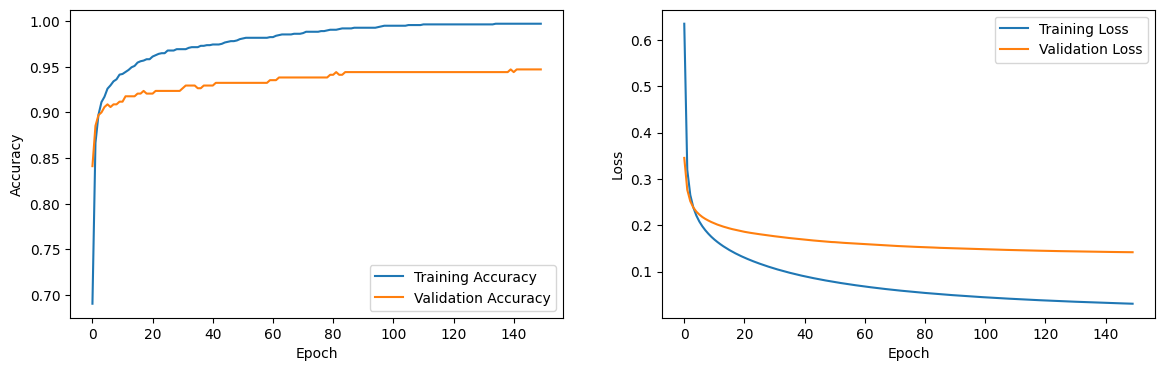

In [10]:
# plot accuracy and loss
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

2024-07-02 14:42:03.798820: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step


2024-07-02 14:42:04.615235: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


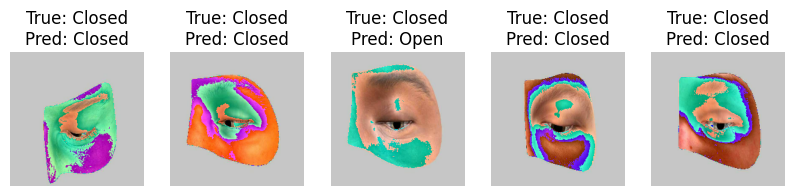

In [11]:
def plot_predictions(model, dataset, class_names = ["Closed", "Open"], num_images=5):
    plt.figure(figsize=(10, 5))
    images_displayed = 0

    for images, labels in dataset.take(1):
        predictions = model.predict(images)
        predicted_labels = tf.argmax(predictions, axis=1)

        for i in range(len(images)):
            if images_displayed >= num_images:
                break

            plt.subplot(1, num_images, images_displayed + 1)
            plt.imshow((images[i].numpy() * 255).astype("uint8"))
            plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[predicted_labels[i]]}")
            plt.axis("off")
            images_displayed += 1

# Plotting predictions from validation data
plot_predictions(model, test_data)